In [1]:
import numpy as np
import matplotlib.pyplot as pp
import pandas as pd
import seaborn

In [2]:
%matplotlib inline

In [3]:
import zipfile
zipfile.ZipFile('names.zip').extractall('.')

In [4]:
import os
os.listdir('names')

['NationalReadMe.pdf',
 'yob1880.txt',
 'yob1881.txt',
 'yob1882.txt',
 'yob1883.txt',
 'yob1884.txt',
 'yob1885.txt',
 'yob1886.txt',
 'yob1887.txt',
 'yob1888.txt',
 'yob1889.txt',
 'yob1890.txt',
 'yob1891.txt',
 'yob1892.txt',
 'yob1893.txt',
 'yob1894.txt',
 'yob1895.txt',
 'yob1896.txt',
 'yob1897.txt',
 'yob1898.txt',
 'yob1899.txt',
 'yob1900.txt',
 'yob1901.txt',
 'yob1902.txt',
 'yob1903.txt',
 'yob1904.txt',
 'yob1905.txt',
 'yob1906.txt',
 'yob1907.txt',
 'yob1908.txt',
 'yob1909.txt',
 'yob1910.txt',
 'yob1911.txt',
 'yob1912.txt',
 'yob1913.txt',
 'yob1914.txt',
 'yob1915.txt',
 'yob1916.txt',
 'yob1917.txt',
 'yob1918.txt',
 'yob1919.txt',
 'yob1920.txt',
 'yob1921.txt',
 'yob1922.txt',
 'yob1923.txt',
 'yob1924.txt',
 'yob1925.txt',
 'yob1926.txt',
 'yob1927.txt',
 'yob1928.txt',
 'yob1929.txt',
 'yob1930.txt',
 'yob1931.txt',
 'yob1932.txt',
 'yob1933.txt',
 'yob1934.txt',
 'yob1935.txt',
 'yob1936.txt',
 'yob1937.txt',
 'yob1938.txt',
 'yob1939.txt',
 'yob1940.txt',
 

In [5]:
open('names/yob2011.txt','r').readlines()[:10]

['Sophia,F,21816\n',
 'Isabella,F,19870\n',
 'Emma,F,18777\n',
 'Olivia,F,17294\n',
 'Ava,F,15480\n',
 'Emily,F,14236\n',
 'Abigail,F,13229\n',
 'Madison,F,12360\n',
 'Mia,F,11512\n',
 'Chloe,F,10970\n']

In [6]:
names2011 = pd.read_csv('names/yob2011.txt')

In [7]:
names2011.head()

,Sophia,F,21816
0,Isabella,F,19870
1,Emma,F,18777
2,Olivia,F,17294
3,Ava,F,15480
4,Emily,F,14236


In [8]:
names2011 = pd.read_csv('names/yob2011.txt',names=['name','sex','number'])

In [9]:
names2011.head()

,name,sex,number
0,Sophia,F,21816
1,Isabella,F,19870
2,Emma,F,18777
3,Olivia,F,17294
4,Ava,F,15480


In [10]:
names_all = []

for year in range(1880,2014+1):
    names_all.append(pd.read_csv('names/yob{}.txt'.format(year),names=['name','sex','number']))
    names_all[-1]['year'] = year

allyears = pd.concat(names_all)

In [11]:
allyears.head()

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


In [12]:
allyears.tail()

,name,sex,number,year
33039,Zykeem,M,5,2014
33040,Zymeer,M,5,2014
33041,Zymiere,M,5,2014
33042,Zyran,M,5,2014
33043,Zyrin,M,5,2014


In [13]:
ay_indexed = allyears.set_index(['sex', 'name','year']).sort_index()

In [16]:
ay_indexed

number
sex name      year        
F   Aabha     2011       7
              2012       5
              2014       9
    Aabriella 2008       5
              2014       5
...                    ...
M   Zytavious 2009       7
              2010       6
    Zyvion    2009       5
    Zyyon     2014       6
    Zzyzx     2010       5

[1825433 rows x 1 columns]

In [17]:
ay_indexed.loc['F'].loc['Marry']

,number
year,
1882,6
1883,6
1887,7
1888,5
1889,6
...,...
2009,11
2010,6
2011,6


In [24]:
ay_indexed.loc['F','Marry']

,number
year,
1882,6
1883,6
1887,7
1888,5
1889,6
...,...
2009,11
2010,6
2011,6


In [29]:
def plotname(sex,name):
    data = ay_indexed.loc[sex, name]

    pp.plot(data.index, data.values)

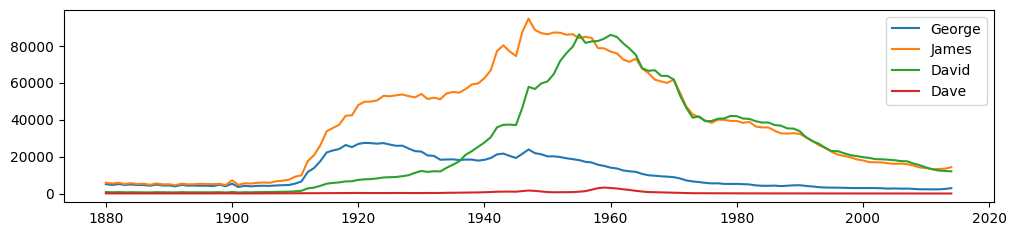

In [40]:
pp.figure(figsize=(12,2.5))

names = ['George', 'James', 'David', 'Dave']

for name in names:
    plotname('M', name)

pp.legend(names)

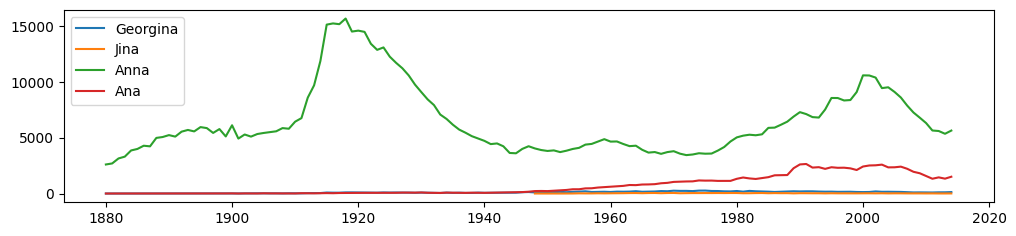

In [41]:
pp.figure(figsize=(12,2.5))

names = ['Georgina', 'Jina', 'Anna', 'Ana']

for name in names:
    plotname('F', name)

pp.legend(names)

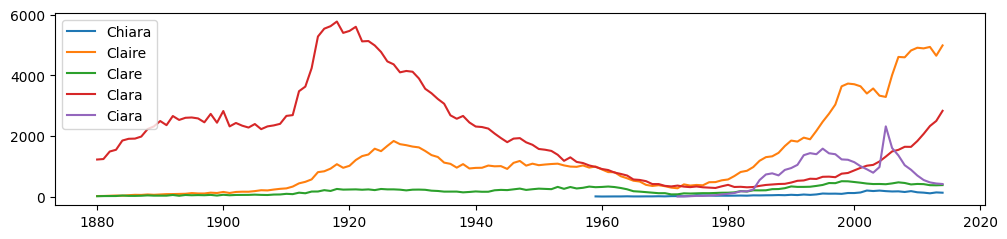

In [42]:
pp.figure(figsize=(12,2.5))

names = ['Chiara', 'Claire', 'Clare', 'Clara', 'Ciara']

for name in names:
    plotname('F', name)

pp.legend(names)

In [45]:
ay_indexed.loc['F'].loc[names].head()

number
name   year        
Chiara 1959       9
       1960       5
       1962       8
       1963       8
       1964      12

In [54]:
ay_indexed.loc['F'].loc[names].unstack('name').head()

number                           
name Chiara Claire Clare   Clara Ciara
year                                  
1880    NaN   21.0  15.0  1226.0   NaN
1881    NaN   23.0  20.0  1242.0   NaN
1882    NaN   30.0  21.0  1490.0   NaN
1883    NaN   38.0  22.0  1548.0   NaN
1884    NaN   33.0  38.0  1852.0   NaN

In [55]:
ay_indexed.loc['F'].loc[names].unstack(level=0).head()

number                           
name Chiara Claire Clare   Clara Ciara
year                                  
1880    NaN   21.0  15.0  1226.0   NaN
1881    NaN   23.0  20.0  1242.0   NaN
1882    NaN   30.0  21.0  1490.0   NaN
1883    NaN   38.0  22.0  1548.0   NaN
1884    NaN   33.0  38.0  1852.0   NaN

In [60]:
ay_indexed.loc['F'].loc[names].unstack(level=0).fillna(0).head()

number                           
name Chiara Claire Clare   Clara Ciara
year                                  
1880    0.0   21.0  15.0  1226.0   0.0
1881    0.0   23.0  20.0  1242.0   0.0
1882    0.0   30.0  21.0  1490.0   0.0
1883    0.0   38.0  22.0  1548.0   0.0
1884    0.0   33.0  38.0  1852.0   0.0

In [66]:
variants = ay_indexed.loc['F'].loc[names].unstack(level=0).fillna(0)

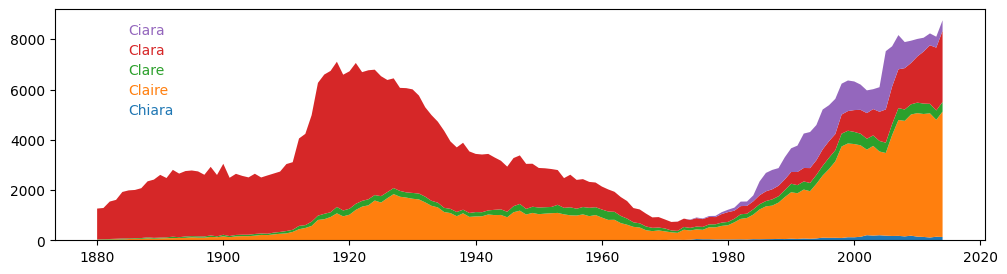

In [85]:
# Handle MultiIndex columns if 'number' is the top level
if isinstance(variants.columns, pd.MultiIndex):
    df_plot = variants['number']
else:
    df_plot = variants

pp.figure(figsize=(12,3))

palette = seaborn.color_palette()
pp.stackplot(df_plot.index, df_plot.values.T, colors=palette)

for i, name in enumerate(df_plot.columns):
    pp.text(1885, 5000 + 800*i, name, color=palette[i])
    
